# 🤖 Clasificación y Reducción de Dimensionalidad — CAP Sleep Database

**Notebook 4 del pipeline.** Se ejecuta **después** de:

1. Análisis exploratorio.
2. Preprocesamiento avanzado (resampleo, normalización de canales, escalado).
3. Extracción de características (ventanas 3 s sin traslape, 30 features/ventana).

Reutiliza los CSVs `caracteristicas_eeg_3s*.csv` exportados por el notebook 3
en `../data/features/`. **No** repite limpieza, ni resampleo, ni extracción.

### Foco exclusivo de este notebook

| Bloque | Técnicas |
|--------|----------|
| **Clasificación supervisada** | Regresión Logística, Random Forest, Perceptrón |
| **Reducción de dimensionalidad** | PCA, Kernel PCA (RBF), SelectKBest + f_classif |
| **Evaluación** | accuracy, precision, recall, F1 (macro y por clase), matrices de confusión |
| **Validación** | división train/test estratificada + división por paciente para evitar fuga |

## 1. Introducción

### 1.1 Clasificación supervisada

Una tarea de **clasificación supervisada** aprende una función
$f: \mathbb{R}^d \to \mathcal{Y}$ desde un conjunto de ejemplos etiquetados
$\{(x_i, y_i)\}$, de forma que prediga la clase $y$ de un nuevo vector de
características $x$. En nuestro caso:

- $x \in \mathbb{R}^{30}$ — las 30 características EEG por ventana de 3 s.
- $y \in \{\text{Bruxismo}, \text{Insomnio}, \text{Narcolepsia}, \ldots\}$ — la
  categoría diagnóstica del paciente.

### 1.2 Reducción de dimensionalidad

**Reducir la dimensionalidad** significa transformar $x \in \mathbb{R}^d$ a
$x' \in \mathbb{R}^{d'}$ con $d' < d$ conservando la mayor cantidad posible
de información útil. Es relevante porque:

- **Maldición de la dimensionalidad** — en espacios de alta dimensión, las
  distancias se concentran y los modelos pierden poder discriminativo.
- **Redundancia entre características** — el heatmap del notebook 3 evidenció
  pares con $|r| > 0.9$ (p. ej. `energía` ↔ `pot_total`).
- **Sobreajuste (overfitting)** — más características que muestras → un modelo
  flexible memoriza ruido en lugar de aprender estructura.
- **Interpretabilidad y velocidad** — menos features = más fácil de explicar
  y entrenar.

### 1.3 ¿Por qué importan ambos en EEG?

El EEG tiene **alta dimensionalidad y mucho ruido**:

- Cada canal aporta decenas de descriptores espectrales y temporales.
- Las características están **fuertemente correlacionadas** (varianza vs RMS,
  energía vs potencia total).
- El **ruido fisiológico** (movimientos, parpadeos, EMG residual) se mezcla
  con la señal de interés.
- Las **clases están desbalanceadas** porque cada cohorte tiene distinto
  número de pacientes y distinta duración de grabación.

Reducir dimensionalidad y elegir un clasificador robusto mitiga estos
problemas.

### 1.4 Entrenamiento, prueba, sobreajuste y generalización

- **Entrenamiento** — el modelo ajusta sus parámetros sobre el 80 % de los
  datos.
- **Prueba** — el modelo se evalúa sobre el 20 % restante, **nunca visto**
  durante el entrenamiento.
- **Sobreajuste** — el modelo aprende patrones específicos del conjunto de
  entrenamiento (incluyendo ruido) y falla en datos nuevos.
- **Generalización** — capacidad del modelo de funcionar bien en datos no
  vistos. Es la métrica que realmente importa.

### 1.5 ⚠️ Fuga de información a nivel paciente

Si dividimos al **azar** las ventanas, ventanas del mismo paciente acaban en
*train* y *test*. Como un paciente tiene cientos de ventanas muy parecidas
entre sí, el modelo "memoriza al paciente", no al trastorno. Esto produce
métricas **artificialmente altas**.

La forma correcta en estudios EEG es dividir **por paciente**: todas las
ventanas de un paciente caen en *train* **o** en *test*, nunca en ambos.
Implementaremos **ambas** estrategias y compararemos sus métricas para
ilustrar el efecto de la fuga.

## 2. Importaciones

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier

# División y validación
from sklearn.model_selection import (
    train_test_split, GroupShuffleSplit, cross_val_score, StratifiedKFold,
)

# Reducción de dimensionalidad
from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import SelectKBest, f_classif

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
print(f'Random state global: {RANDOM_STATE}')

Random state global: 42


## 3. Carga de datasets de características

Reutilizamos los CSVs generados por el notebook 3:

| Archivo | Contenido |
|---------|-----------|
| `caracteristicas_eeg_3s.csv` | Características sin escalar (referencia) |
| `caracteristicas_eeg_3s_standard.csv` | Escaladas con `StandardScaler` |
| `caracteristicas_eeg_3s_minmax.csv` | Escaladas con `MinMaxScaler` |
| `caracteristicas_eeg_3s_robust.csv` | Escaladas con `RobustScaler` |
| `metadata_caracteristicas.csv` | Descripción de cada columna |

> Trabajaremos por defecto sobre **`caracteristicas_eeg_3s_standard.csv`**
> porque ya está estandarizado (media 0, desviación 1 por característica), lo
> cual es indispensable para modelos lineales (regresión logística,
> perceptrón) y métodos basados en distancias (Kernel PCA).

In [2]:
FEATURES_DIR = Path.cwd() / '../data/features'
PROCESSED_DIR = Path.cwd() / '../data/processed'
RESULTS_DIR  = Path.cwd() / '../data/results'
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

def cargar_csv(nombre):
    ruta = FEATURES_DIR / nombre
    if not ruta.exists():
        raise FileNotFoundError(
            f'No se encontró {ruta}. Ejecuta primero el notebook de '
            'extracción de características.'
        )
    return pd.read_csv(ruta)

df_raw      = cargar_csv('caracteristicas_eeg_3s.csv')
df_standard = cargar_csv('caracteristicas_eeg_3s_standard.csv')
df_minmax   = cargar_csv('caracteristicas_eeg_3s_minmax.csv')
df_robust   = cargar_csv('caracteristicas_eeg_3s_robust.csv')

# Metadata de columnas
try:
    metadata = pd.read_csv(FEATURES_DIR / 'metadata_caracteristicas.csv')
    print(f'Metadata cargada: {len(metadata)} columnas descritas')
except FileNotFoundError:
    metadata = None
    print('⚠️  metadata_caracteristicas.csv no encontrado (no es bloqueante).')

print(f'\nDimensiones de los datasets:')
for nombre, d in [('raw', df_raw), ('standard', df_standard),
                  ('minmax', df_minmax), ('robust', df_robust)]:
    print(f'  {nombre:<10}: {d.shape}')

Metadata cargada: 36 columnas descritas

Dimensiones de los datasets:
  raw       : (656930, 36)
  standard  : (656930, 36)
  minmax    : (656930, 36)
  robust    : (656930, 36)


In [3]:
# Vista previa
print('Primeras filas (dataset estandarizado):')
df_standard.head(5).round(3)

Primeras filas (dataset estandarizado):


,patient,disorder,channel,ch_category,window_idx,onset_s,media,mediana,std,varianza,...,pot_beta_rel,pot_gamma,pot_gamma_rel,freq_dominante,freq_mediana,hjorth_activity,hjorth_mobility,hjorth_complexity,entropia_shannon,entropia_espectral
0,brux1,Bruxismo,Fp2-F4,EEG,0,0,0.616,0.320,0.347,-0.016,...,0.033,0.011,0.173,0.060,-0.203,-0.016,0.348,-0.250,-1.508,0.262
1,brux1,Bruxismo,Fp2-F4,EEG,1,3,-0.082,0.092,0.431,-0.005,...,-0.186,0.002,-0.030,0.060,-0.203,-0.005,0.159,-0.087,-3.054,-0.026
2,brux1,Bruxismo,Fp2-F4,EEG,2,6,0.064,0.082,-0.328,-0.078,...,1.373,-0.029,0.295,0.060,0.098,-0.078,0.890,-0.358,-2.729,1.205
3,brux1,Bruxismo,Fp2-F4,EEG,3,9,-1.324,-0.462,-0.149,-0.066,...,0.151,-0.026,0.438,-0.279,-0.353,-0.066,-0.132,0.208,-1.071,-0.025
4,brux1,Bruxismo,Fp2-F4,EEG,4,12,-0.314,-0.007,0.211,-0.032,...,3.132,0.016,0.218,1.757,1.301,-0.032,1.006,-0.665,-5.844,1.650


In [4]:
# Tipos de columnas y nulos
print('Tipos y completitud (dataset estandarizado):')
info = pd.DataFrame({
    'tipo':     df_standard.dtypes.astype(str),
    'no_nulos': df_standard.notna().sum(),
    'nulos':    df_standard.isna().sum(),
    '%_nulos':  (df_standard.isna().sum() / len(df_standard) * 100).round(2),
})
print(info.to_string())

Tipos y completitud (dataset estandarizado):
                       tipo  no_nulos  nulos  %_nulos
patient                 str    656930      0      0.0
disorder                str    656930      0      0.0
channel                 str    656930      0      0.0
ch_category             str    656930      0      0.0
window_idx            int64    656930      0      0.0
onset_s               int64    656930      0      0.0
media               float64    656930      0      0.0
mediana             float64    656930      0      0.0
std                 float64    656930      0      0.0
varianza            float64    656930      0      0.0
rms                 float64    656930      0      0.0
energia             float64    656930      0      0.0
maximo              float64    656930      0      0.0
minimo              float64    656930      0      0.0
rango               float64    656930      0      0.0
skewness            float64    656930      0      0.0
kurtosis            float64    656930

In [5]:
# Distribución de clases (a nivel ventana)
distrib = df_standard['disorder'].value_counts()
print('Distribución de clases (ventanas):')
print(distrib.to_string())
print(f'\nTotal ventanas: {len(df_standard):,}')
print(f'Pacientes únicos: {df_standard["patient"].nunique()}')
print(f'Ratio max/min: {distrib.max() / distrib.min():.1f}×')

Distribución de clases (ventanas):
disorder
Epilepsia nocturna frontal    141440
Movimientos periódicos        118440
Normal                         80780
Insomnio                       80000
Trastorno REM                  70630
Bruxismo                       62140
Narcolepsia                    56400
Trastorno respiratorio         47100

Total ventanas: 656,930
Pacientes únicos: 8
Ratio max/min: 3.0×


## 4. Preparación de datos

### 4.1 Separación de predictores y etiquetas

- **`X`** — las 30 características numéricas (`media`, `pot_alpha_rel`,
  `hjorth_complexity`, …).
- **`y`** — la columna `disorder` (categoría diagnóstica del paciente).
- **`groups`** — la columna `patient`, necesaria para la división por paciente
  más adelante.

### 4.2 Columnas descartadas

Excluimos:

- `patient`, `channel`, `ch_category` — identificadores categóricos.
- `window_idx`, `onset_s` — metadatos temporales (no son features
  estadísticamente válidas).
- `disorder` — la variable objetivo.

### 4.3 ¿Qué representan las clases?

Cada paciente trae una **etiqueta a nivel paciente** que codifica la patología
clínica con la que fue admitido al estudio (Bruxismo, Insomnio,
Narcolepsia, NFLE, PLM, RBD, SDB, Normal). Esto significa que **todas las
ventanas** de un paciente comparten la misma etiqueta, lo cual tiene
limitaciones:

- Una ventana de un paciente narcoléptico mientras está en N3 profundo
  probablemente no es distinguible de la misma ventana de un control.
- La etiqueta refleja el **diagnóstico del paciente**, no el estado fisiológico
  instantáneo de la ventana.
- Lo ideal sería etiqueta por época AASM (W/N1/N2/N3/REM) o por evento CAP,
  pero requiere alinear `onset_s` con `stages_all` del notebook 1.

### 4.4 Validaciones

In [6]:
# Columnas a excluir del set de features
COLS_META = ['patient', 'disorder', 'channel', 'ch_category',
             'window_idx', 'onset_s']
CARACT_COLS = [c for c in df_standard.columns if c not in COLS_META]

print(f'Características usadas como predictoras ({len(CARACT_COLS)}):')
print(' | '.join(CARACT_COLS))

Características usadas como predictoras (30):
media | mediana | std | varianza | rms | energia | maximo | minimo | rango | skewness | kurtosis | zcr | pot_total | pot_delta | pot_delta_rel | pot_theta | pot_theta_rel | pot_alpha | pot_alpha_rel | pot_beta | pot_beta_rel | pot_gamma | pot_gamma_rel | freq_dominante | freq_mediana | hjorth_activity | hjorth_mobility | hjorth_complexity | entropia_shannon | entropia_espectral


In [7]:
# Construcción de X, y y groups sobre el dataset estandarizado
X = df_standard[CARACT_COLS].copy()
y = df_standard['disorder'].copy()
groups = df_standard['patient'].copy()

# Validación 1: nulos
n_nulos = X.isna().sum().sum()
print(f'NaN totales en X: {n_nulos}')

# Validación 2: infinitos
n_inf = np.isinf(X.values).sum()
print(f'Infinitos en X : {n_inf}')

# Validación 3: columnas constantes
std_por_col = X.std()
constantes = std_por_col[std_por_col == 0].index.tolist()
print(f'Columnas constantes: {constantes if constantes else "ninguna"}')

# Limpieza si hubiera problemas
if n_nulos > 0:
    print('  → Imputando NaN con la mediana por columna.')
    X = X.fillna(X.median())
if n_inf > 0:
    print('  → Reemplazando inf por el percentil 99 de cada columna.')
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
if constantes:
    print(f'  → Eliminando columnas constantes: {constantes}')
    X = X.drop(columns=constantes)
    CARACT_COLS = [c for c in CARACT_COLS if c not in constantes]

print(f'\nDimensión final de X: {X.shape}')
print(f'Clases en y         : {sorted(y.unique())}')
print(f'Pacientes en groups : {groups.nunique()}')

NaN totales en X: 0
Infinitos en X : 0
Columnas constantes: ninguna

Dimensión final de X: (656930, 30)
Clases en y         : ['Bruxismo', 'Epilepsia nocturna frontal', 'Insomnio', 'Movimientos periódicos', 'Narcolepsia', 'Normal', 'Trastorno REM', 'Trastorno respiratorio']
Pacientes en groups : 8


## 5. División entrenamiento / prueba

Generamos **dos** divisiones distintas y las usaremos a lo largo del notebook:

### 5.1 División A — Estratificada al azar (window-level, **con fuga**)

Mantiene la proporción de clases pero **NO respeta los grupos**: ventanas del
mismo paciente pueden caer en ambos lados. Es la división "tradicional" y
sirve como **referencia optimista**.

### 5.2 División B — Por paciente (group-level, **sin fuga**)

`GroupShuffleSplit` garantiza que un paciente solo aparece en *train* **o** en
*test*. Esta es la división **clínicamente válida** y la que reportaríamos
en un paper.

En ambos casos: 80 % train / 20 % test, `random_state=42`.

### 5.3 ¿Por qué dividir?

Reservar un conjunto **no usado durante el entrenamiento** es la única
manera de medir la **capacidad de generalización**: si el modelo memorizó el
entrenamiento (overfit), el test lo delatará con métricas pobres. Sin esta
separación, las métricas reflejan únicamente la capacidad del modelo de
recordar.

In [8]:
# ── División A: estratificada al azar (con potencial fuga) ──
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('División A — Estratificada (window-level):')
print(f'  Train: {X_train_A.shape[0]:,} ventanas')
print(f'  Test : {X_test_A.shape[0]:,} ventanas')
print(f'  Proporción Train: clases\n{y_train_A.value_counts(normalize=True).round(3).to_string()}')

División A — Estratificada (window-level):
  Train: 525,544 ventanas
  Test : 131,386 ventanas
  Proporción Train: clases
disorder
Epilepsia nocturna frontal    0.215
Movimientos periódicos        0.180
Normal                        0.123
Insomnio                      0.122
Trastorno REM                 0.108
Bruxismo                      0.095
Narcolepsia                   0.086
Trastorno respiratorio        0.072


In [9]:
# ── División B: por paciente (sin fuga) ──
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_B = X.iloc[train_idx].reset_index(drop=True)
X_test_B  = X.iloc[test_idx].reset_index(drop=True)
y_train_B = y.iloc[train_idx].reset_index(drop=True)
y_test_B  = y.iloc[test_idx].reset_index(drop=True)
g_train_B = groups.iloc[train_idx].reset_index(drop=True)
g_test_B  = groups.iloc[test_idx].reset_index(drop=True)

print('División B — Por paciente (GroupShuffleSplit):')
print(f'  Train: {X_train_B.shape[0]:,} ventanas — pacientes: {sorted(g_train_B.unique())}')
print(f'  Test : {X_test_B.shape[0]:,} ventanas — pacientes: {sorted(g_test_B.unique())}')
print(f'\n  Solapamiento de pacientes train/test: '
      f'{set(g_train_B) & set(g_test_B)} (debe ser conjunto vacío)')

print(f'\n  Distribución de clases en Train (B):\n{y_train_B.value_counts().to_string()}')
print(f'\n  Distribución de clases en Test (B):\n{y_test_B.value_counts().to_string()}')

División B — Por paciente (GroupShuffleSplit):
  Train: 458,490 ventanas — pacientes: ['brux1', 'n1', 'narco1', 'nfle1', 'rbd1', 'sdb1']
  Test : 198,440 ventanas — pacientes: ['ins1', 'plm1']

  Solapamiento de pacientes train/test: set() (debe ser conjunto vacío)

  Distribución de clases en Train (B):
disorder
Epilepsia nocturna frontal    141440
Normal                         80780
Trastorno REM                  70630
Bruxismo                       62140
Narcolepsia                    56400
Trastorno respiratorio         47100

  Distribución de clases en Test (B):
disorder
Movimientos periódicos    118440
Insomnio                   80000


## 6. Entrenamiento de clasificadores

Entrenamos los **tres modelos** solicitados sobre la **División A**
(window-level). En la sección 11 repetiremos con reducción de dimensionalidad
y con la División B para comparación honesta.

### 6.1 Regresión logística

Modelo lineal probabilístico que estima
$P(y = c \mid x) = \dfrac{e^{w_c^\top x + b_c}}{\sum_k e^{w_k^\top x + b_k}}$.

- **Ventajas:** rápido, interpretable (coeficientes = pesos por feature),
  línea base obligatoria para todo problema de clasificación.
- **Desventajas:** asume frontera de decisión lineal; falla si las clases no
  son linealmente separables.
- **Sensibilidad:** requiere features **escaladas** (lo cual ya tenemos).
- **Comportamiento esperado en EEG:** correcto si las características
  espectrales son aproximadamente lineales con la clase, pobre si requiere
  combinaciones no lineales.

### 6.2 Random Forest

Ensamble de árboles de decisión entrenados con muestreo bootstrap y
selección aleatoria de features por nodo. La predicción es la **moda** sobre
los árboles.

- **Ventajas:** maneja bien **datos complejos**, captura no linealidades,
  robusto a outliers, no requiere escalado, ofrece importancia de features.
- **Desventajas:** modelo grande, menos interpretable, puede sobreajustarse si
  los árboles son muy profundos.
- **Comportamiento esperado en EEG:** suele ser el mejor de los tres porque
  las relaciones entre bandas EEG y patología no son lineales.

### 6.3 Perceptrón

Modelo lineal de origen histórico (Rosenblatt 1958). Aprende un **hiperplano**
$w^\top x + b = 0$ que separa las clases:

- En 2D un hiperplano es una recta; en 3D un plano; en $\mathbb{R}^d$ un
  subespacio de dimensión $d-1$.
- Para datos **linealmente separables** converge en finito; en otro caso
  oscila.
- **Ventajas:** muy rápido, base teórica del perceptrón multicapa (redes
  neuronales).
- **Desventajas:** no produce probabilidades, sensible a inicialización y al
  orden de los datos, vulnerable al ruido EEG.
- **Comportamiento esperado en EEG:** típicamente peor que regresión
  logística porque no usa optimización suave (no minimiza una pérdida
  convexa).

### 6.4 Impacto del escalamiento en modelos lineales

La regresión logística y el perceptrón actualizan pesos proporcionalmente a
$\partial \text{Loss}/\partial w \propto x$. Si una feature tiene escala
$10^3$ y otra $10^{-3}$, los pasos de gradiente son numéricamente inestables
y el modelo converge a una solución sesgada. El escalado a media 0 / std 1
**iguala el peso del gradiente** entre features. Random Forest no se ve
afectado porque las particiones de los árboles son invariantes al escalado
monotónico.

In [10]:
def evaluar_modelo(modelo, X_tr, X_te, y_tr, y_te, nombre):
    '''
    Entrena un modelo, predice sobre test y devuelve un diccionario con
    accuracy, precision, recall y F1 (todos macro).
    '''
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    return {
        'modelo':    nombre,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_te, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_te, y_pred, average='macro', zero_division=0),
        'y_pred':    y_pred,
        'modelo_fit': modelo,
    }


def construir_modelos():
    '''Devuelve un dict {nombre: instancia} con los tres clasificadores.'''
    return {
        'Regresión Logística': LogisticRegression(
            max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE,
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=None,
            class_weight='balanced', n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        'Perceptrón': Perceptron(
            max_iter=2000, tol=1e-4,
            random_state=RANDOM_STATE,
        ),
    }


# Entrenamiento sobre la División A (con fuga, optimista)
print('Entrenando clasificadores sobre División A (window-level)...')
print('=' * 65)

resultados_A = {}
for nombre, modelo in construir_modelos().items():
    res = evaluar_modelo(modelo, X_train_A, X_test_A, y_train_A, y_test_A, nombre)
    resultados_A[nombre] = res
    print(f'\n[{nombre}]')
    print(f'  accuracy : {res["accuracy"]:.4f}')
    print(f'  precision: {res["precision"]:.4f}')
    print(f'  recall   : {res["recall"]:.4f}')
    print(f'  F1 macro : {res["f1"]:.4f}')

Entrenando clasificadores sobre División A (window-level)...

[Regresión Logística]
  accuracy : 0.4387
  precision: 0.4688
  recall   : 0.4061
  F1 macro : 0.4136

[Random Forest]
  accuracy : 0.6782
  precision: 0.6852
  recall   : 0.6668
  F1 macro : 0.6696

[Perceptrón]
  accuracy : 0.3315
  precision: 0.3143
  recall   : 0.2737
  F1 macro : 0.2671


In [11]:
# Reportes de clasificación detallados (División A)
for nombre, res in resultados_A.items():
    print(f'\n══════════ {nombre} — División A ══════════')
    print(classification_report(y_test_A, res['y_pred'], zero_division=0))


══════════ Regresión Logística — División A ══════════
                            precision    recall  f1-score   support

                  Bruxismo       0.65      0.61      0.63     12428
Epilepsia nocturna frontal       0.36      0.57      0.44     28288
                  Insomnio       0.42      0.21      0.28     16000
    Movimientos periódicos       0.43      0.51      0.46     23688
               Narcolepsia       0.46      0.40      0.43     11280
                    Normal       0.41      0.43      0.42     16156
             Trastorno REM       0.65      0.44      0.53     14126
    Trastorno respiratorio       0.38      0.07      0.12      9420

                  accuracy                           0.44    131386
                 macro avg       0.47      0.41      0.41    131386
              weighted avg       0.45      0.44      0.43    131386


══════════ Random Forest — División A ══════════
                            precision    recall  f1-score   support

      

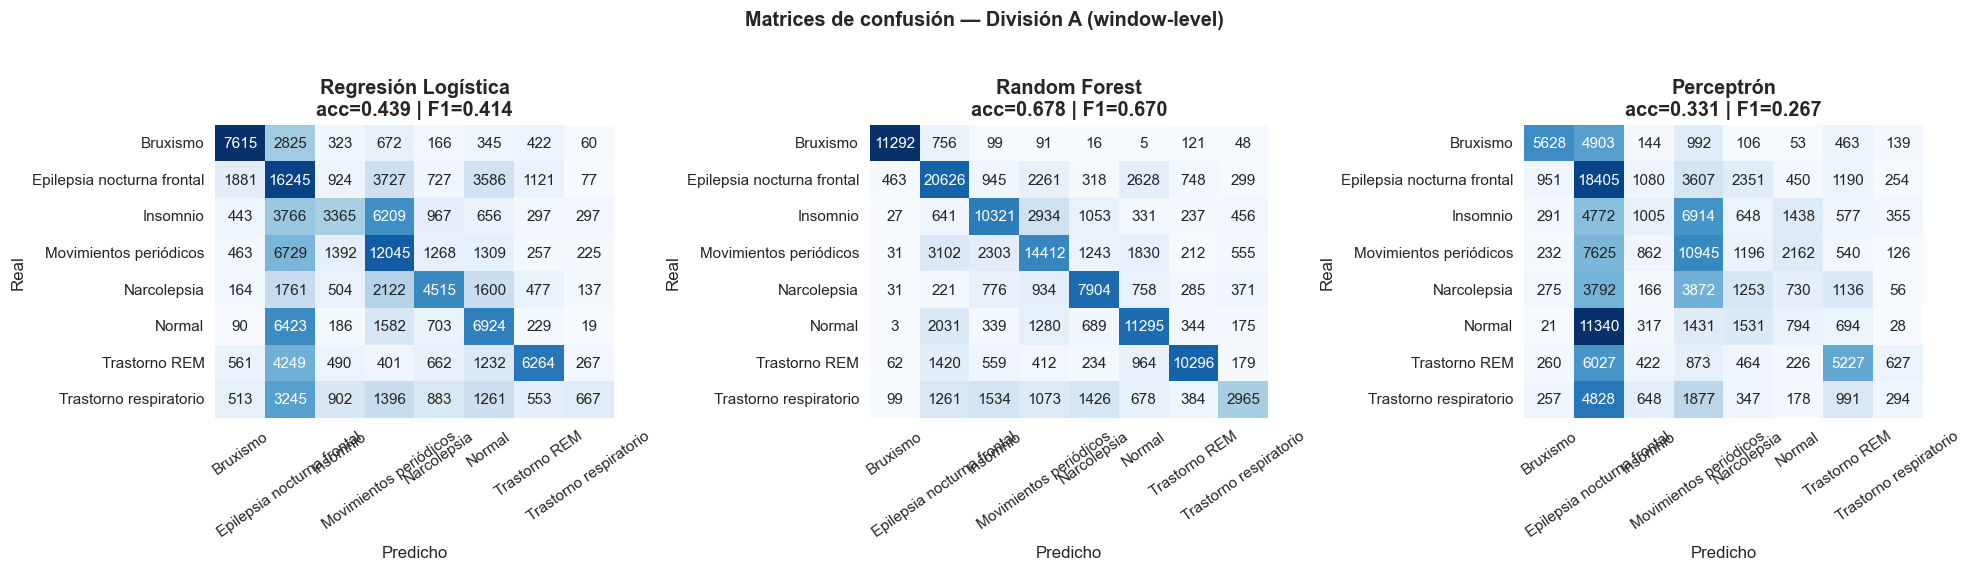

In [12]:
# Matrices de confusión — División A
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clases = sorted(y.unique())

for ax, (nombre, res) in zip(axes, resultados_A.items()):
    cm = confusion_matrix(y_test_A, res['y_pred'], labels=clases)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', cmap='Blues',
        xticklabels=clases, yticklabels=clases,
        cbar=False, ax=ax,
    )
    ax.set_title(f'{nombre}\nacc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('Matrices de confusión — División A (window-level)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 7. Comparación de modelos

Resumimos las cuatro métricas en una tabla y un gráfico de barras.

In [13]:
tabla_A = pd.DataFrame([
    {k: v for k, v in r.items() if k in ('modelo', 'accuracy', 'precision', 'recall', 'f1')}
    for r in resultados_A.values()
])
tabla_A = tabla_A.set_index('modelo').round(4)
print('Tabla comparativa (División A):')
print(tabla_A.to_string())

Tabla comparativa (División A):
                     accuracy  precision  recall      f1
modelo                                                  
Regresión Logística    0.4387     0.4688  0.4061  0.4136
Random Forest          0.6782     0.6852  0.6668  0.6696
Perceptrón             0.3315     0.3143  0.2737  0.2671


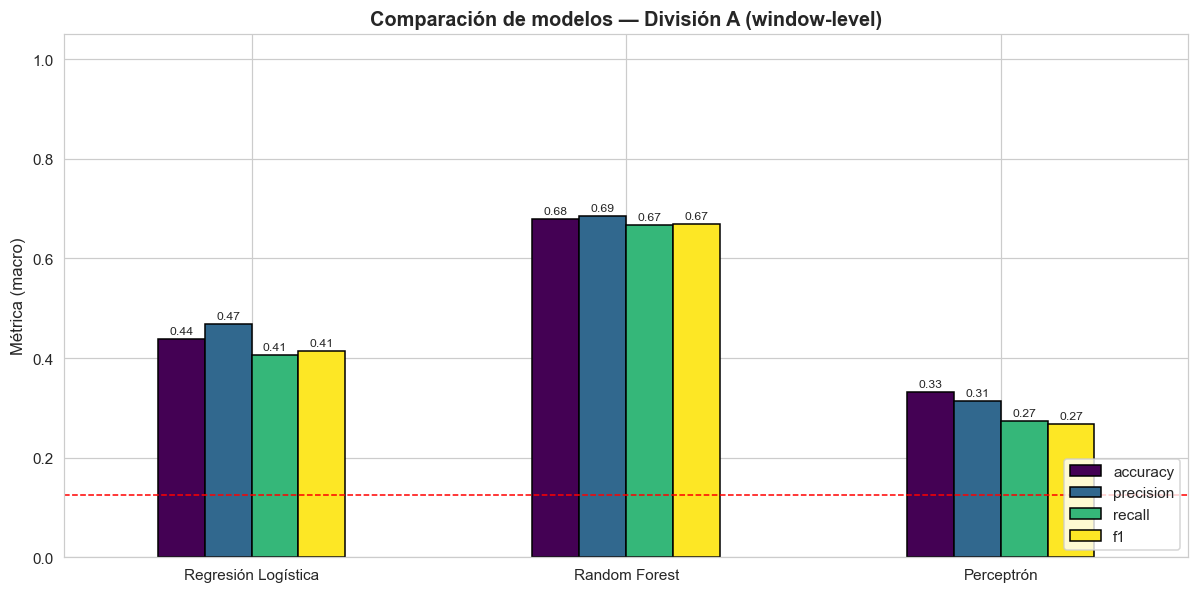

In [14]:
fig, ax = plt.subplots(figsize=(11, 5.5))
tabla_A.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Comparación de modelos — División A (window-level)',
             fontweight='bold')
ax.set_ylabel('Métrica (macro)')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.axhline(1.0 / y.nunique(), color='red', linestyle='--',
           label=f'Línea base aleatoria ({1.0/y.nunique():.3f})', linewidth=1)
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## 8. Reducción de dimensionalidad — PCA

### 8.1 Fundamento matemático

**PCA** (Principal Component Analysis) busca direcciones ortogonales en
$\mathbb{R}^d$ que **maximizan la varianza** de los datos proyectados:

1. Centrar la matriz de datos $X$ (restar la media por columna).
2. Calcular la matriz de covarianza $C = \frac{1}{n-1} X^\top X$ ($d \times d$).
3. Diagonalizar: $C = V \Lambda V^\top$. Las columnas de $V$ son los
   **componentes principales**; los $\lambda_i$ de $\Lambda$ (ordenados de
   mayor a menor) miden la varianza capturada por cada componente.
4. La proyección a $d'$ dimensiones se obtiene como $X_{\text{red}} = X V_{1:d'}$.

### 8.2 Concepto clave: varianza explicada

$$\text{explained\_variance\_ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

Indica qué fracción de la variabilidad total captura cada componente. La
**suma acumulada** dice cuántos componentes necesitamos para conservar (por
ejemplo) el 95 % de la información.

### 8.3 ¿Por qué PCA en EEG?

Las características EEG presentan **redundancia**: `pot_total` y `energia`
están casi perfectamente correlacionadas, igual que `std` y `rms`, o las
distintas bandas y sus versiones relativas. PCA "comprime" toda esa
redundancia en pocos ejes, reduciendo el ruido y la dimensionalidad sin
descartar información discriminativa.

### 8.4 Reducción **lineal**

PCA solo encuentra estructura **lineal** en los datos. Si las clases viven en
una variedad curva, PCA puede no separarlas bien; para eso existe Kernel PCA
(sección 9).

Componentes necesarios para 95 % de varianza: 14 / 30


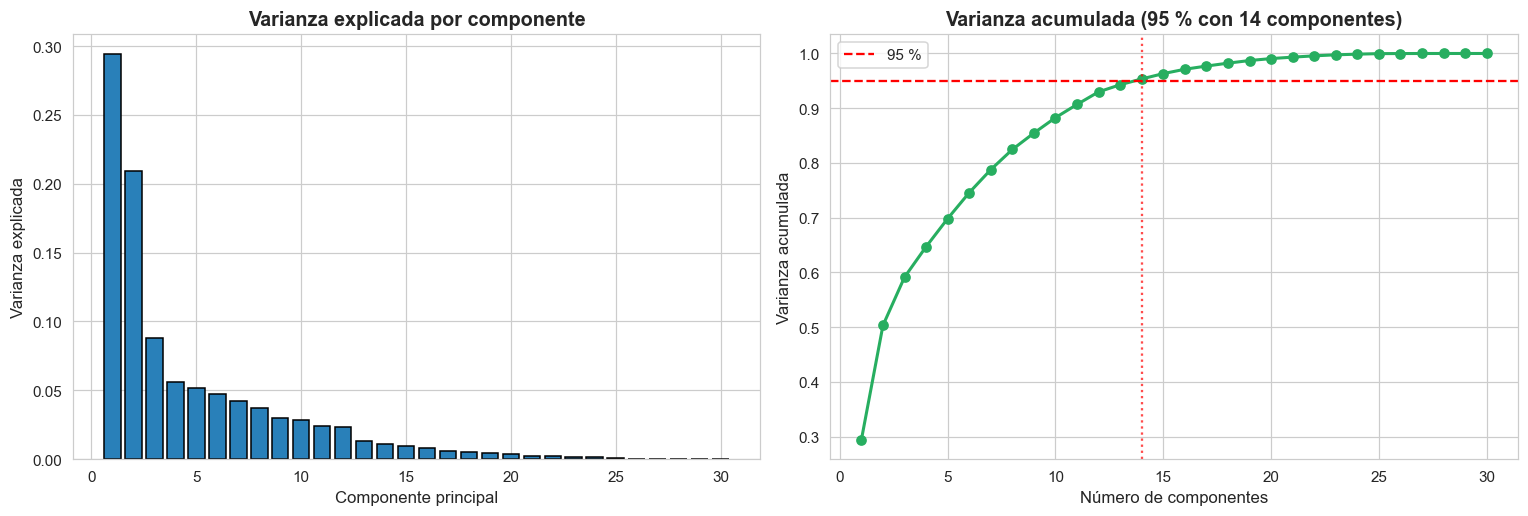

In [15]:
# Ajustar PCA con todos los componentes para ver la curva acumulada
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_train_A)

var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Componentes para conservar 95 % de varianza
n_95 = int(np.searchsorted(var_acumulada, 0.95) + 1)
print(f'Componentes necesarios para 95 % de varianza: {n_95} / {len(var_acumulada)}')

# Gráfica de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_,
            color='#2980B9', edgecolor='black')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente', fontweight='bold')

axes[1].plot(range(1, len(var_acumulada) + 1), var_acumulada,
             marker='o', linewidth=2, color='#27AE60')
axes[1].axhline(0.95, color='red', linestyle='--', label='95 %')
axes[1].axvline(n_95, color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title(f'Varianza acumulada (95 % con {n_95} componentes)',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

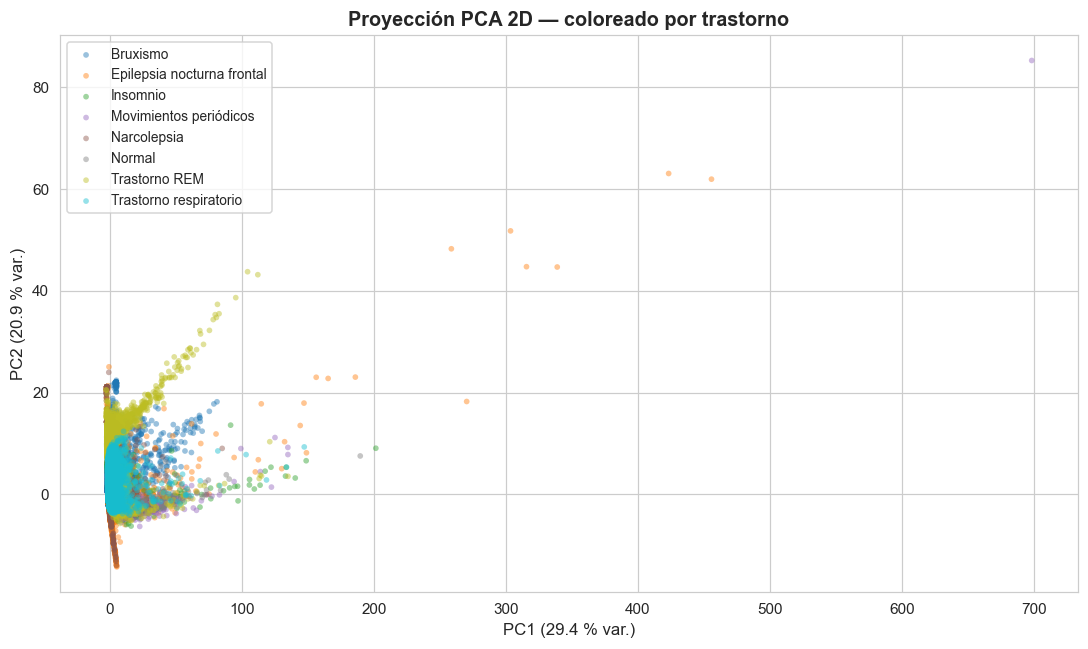

Varianza acumulada en 2D: 50.3 %


In [16]:
# Proyección 2D para visualización
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2d.fit_transform(X_train_A)

fig, ax = plt.subplots(figsize=(10, 6))
clases_orden = sorted(y_train_A.unique())
colores = plt.cm.tab10(np.linspace(0, 1, len(clases_orden)))

for clase, color in zip(clases_orden, colores):
    mask = y_train_A.values == clase
    ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
               alpha=0.45, s=14, color=color, label=clase, edgecolor='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f} % var.)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f} % var.)')
ax.set_title('Proyección PCA 2D — coloreado por trastorno', fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Varianza acumulada en 2D: {pca_2d.explained_variance_ratio_.sum() * 100:.1f} %')

In [17]:
# PCA con n_95 componentes para usar en clasificación más adelante
pca_optimo = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_train_A_pca = pca_optimo.fit_transform(X_train_A)
X_test_A_pca  = pca_optimo.transform(X_test_A)

print(f'Forma original    : {X_train_A.shape}')
print(f'Forma tras PCA    : {X_train_A_pca.shape}')
print(f'Varianza retenida : {pca_optimo.explained_variance_ratio_.sum() * 100:.2f} %')

Forma original    : (525544, 30)
Forma tras PCA    : (525544, 14)
Varianza retenida : 95.35 %


## 9. Kernel PCA

### 9.1 ¿Qué cambia respecto a PCA clásico?

PCA opera en el espacio original; Kernel PCA primero aplica un **mapeo
implícito** $\phi: \mathbb{R}^d \to \mathcal{H}$ a un espacio de mayor
dimensión y luego hace PCA allí. El truco del **kernel** evita calcular
$\phi$ explícitamente: solo se necesita la función $k(x_i, x_j) = \phi(x_i)^\top \phi(x_j)$.

### 9.2 Kernel RBF (Gaussiano)

$$k(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$

Captura **estructura local**: dos puntos cercanos en $\mathbb{R}^d$ tienen
similaridad cercana a 1; dos lejanos, cercana a 0. Permite separar clases
que en PCA lineal aparecen entremezcladas.

### 9.3 Utilidad en EEG

Las relaciones entre características EEG y patología son **no lineales**:

- Un mismo nivel de `pot_delta_rel` puede corresponder a N3 profundo o a
  artefacto.
- La interacción entre `hjorth_complexity` y `entropia_espectral` distingue
  vigilia de REM, pero la frontera no es una línea recta en el plano.

Kernel PCA puede revelar estas estructuras curvas. Su costo es
computacional: $O(n^3)$ y requiere matriz kernel $n \times n$, así que lo
aplicamos sobre una **muestra** del dataset.

Submuestra para Kernel PCA: (3000, 30)


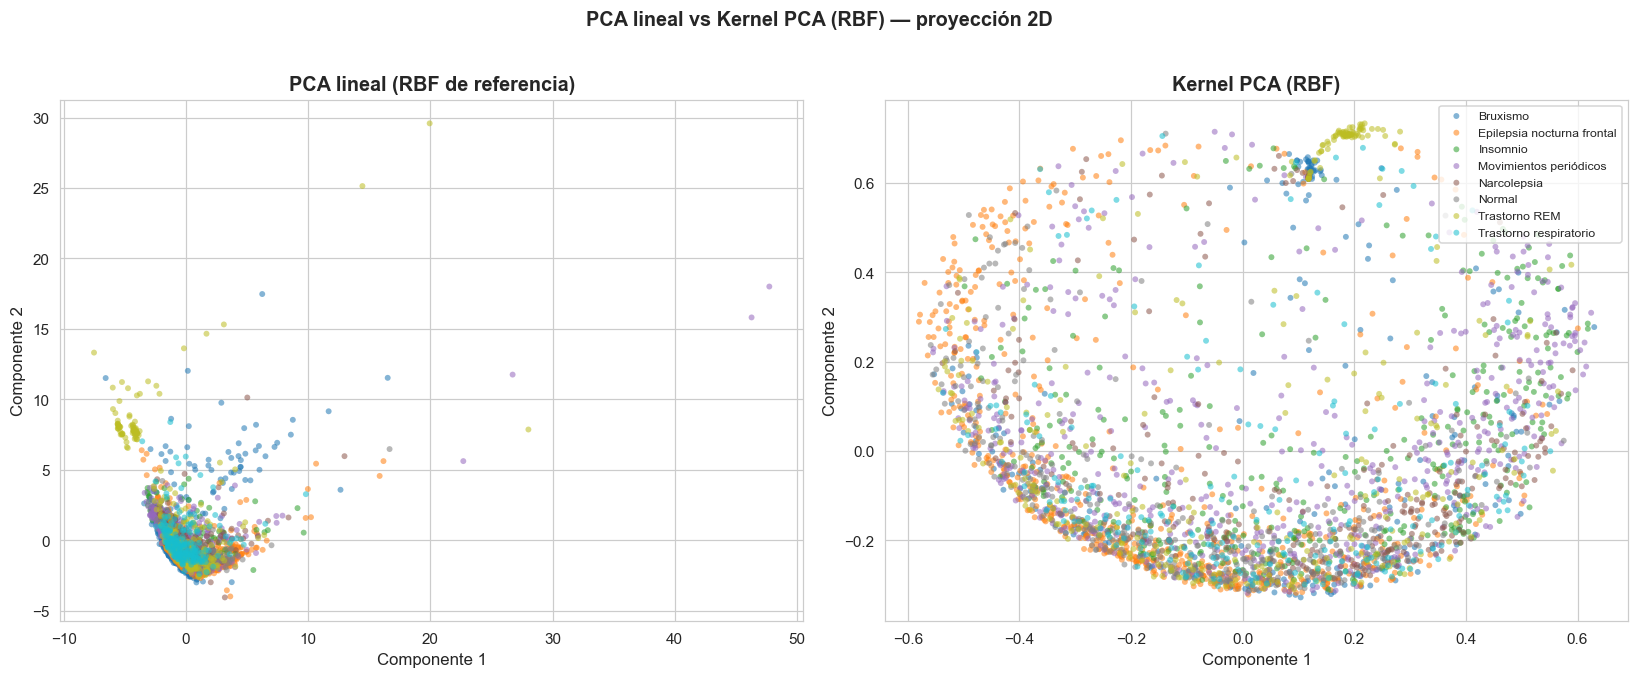

In [18]:
# Submuestreo estratificado para que Kernel PCA sea tratable
N_MUESTRA = min(3000, len(X_train_A))
X_sample, _, y_sample, _ = train_test_split(
    X_train_A, y_train_A,
    train_size=N_MUESTRA,
    random_state=RANDOM_STATE,
    stratify=y_train_A,
)
print(f'Submuestra para Kernel PCA: {X_sample.shape}')

kpca = KernelPCA(
    n_components=2, kernel='rbf', gamma=None,  # gamma=None → 1/n_features
    random_state=RANDOM_STATE,
)
X_sample_kpca = kpca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
clases_orden = sorted(y_sample.unique())
colores = plt.cm.tab10(np.linspace(0, 1, len(clases_orden)))

# PCA lineal sobre la misma submuestra (para comparación 1:1)
pca_demo = PCA(n_components=2, random_state=RANDOM_STATE)
X_sample_pca = pca_demo.fit_transform(X_sample)

for ax, datos, titulo in zip(
    axes,
    [X_sample_pca, X_sample_kpca],
    ['PCA lineal (RBF de referencia)', 'Kernel PCA (RBF)']
):
    for clase, color in zip(clases_orden, colores):
        mask = y_sample.values == clase
        ax.scatter(datos[mask, 0], datos[mask, 1],
                   alpha=0.55, s=15, color=color, label=clase, edgecolor='none')
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.set_title(titulo, fontweight='bold')

axes[1].legend(loc='best', fontsize=8)
plt.suptitle('PCA lineal vs Kernel PCA (RBF) — proyección 2D',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Selección de características — SelectKBest + f_classif

### 10.1 ¿Qué hace SelectKBest?

A diferencia de PCA (que **crea** componentes combinando features), la
selección de features **elige un subconjunto** de las features originales. La
ventaja: el resultado sigue siendo **interpretable** (sabemos qué se quedó).

### 10.2 ¿Qué es `f_classif`?

Calcula la estadística F de **ANOVA** para cada feature individual:

$$F = \frac{\text{varianza entre clases}}{\text{varianza dentro de clases}}$$

- Un valor **alto** indica que la feature **distingue bien** entre clases.
- Es **univariado**: no considera interacciones entre features.

### 10.3 Limitaciones

- No captura información combinada (dos features inútiles individualmente
  pueden ser muy útiles juntas).
- Sensible a outliers.
- Asume relación monotónica con la clase.

A pesar de esto, es un excelente **filtro rápido** y proporciona un ranking
interpretable.

In [19]:
K_BEST = 10  # nos quedamos con las 10 mejores

selector = SelectKBest(score_func=f_classif, k=K_BEST)
selector.fit(X_train_A, y_train_A)

ranking = pd.DataFrame({
    'caracteristica': CARACT_COLS,
    'F_score':        selector.scores_,
    'p_value':        selector.pvalues_,
}).sort_values('F_score', ascending=False).reset_index(drop=True)
ranking['rank'] = ranking.index + 1

print(f'Top {K_BEST} características según F-score (f_classif):')
print(ranking.head(K_BEST).to_string(index=False))

Top 10 características según F-score (f_classif):
    caracteristica      F_score  p_value  rank
               zcr 19007.904135      0.0     1
     pot_gamma_rel 16119.444993      0.0     2
   hjorth_mobility 15486.701012      0.0     3
  entropia_shannon 12761.889811      0.0     4
     pot_delta_rel 11477.418041      0.0     5
     pot_alpha_rel 10988.591341      0.0     6
entropia_espectral 10424.508931      0.0     7
      freq_mediana  9080.375880      0.0     8
      pot_beta_rel  8827.566071      0.0     9
     pot_theta_rel  7979.834513      0.0    10


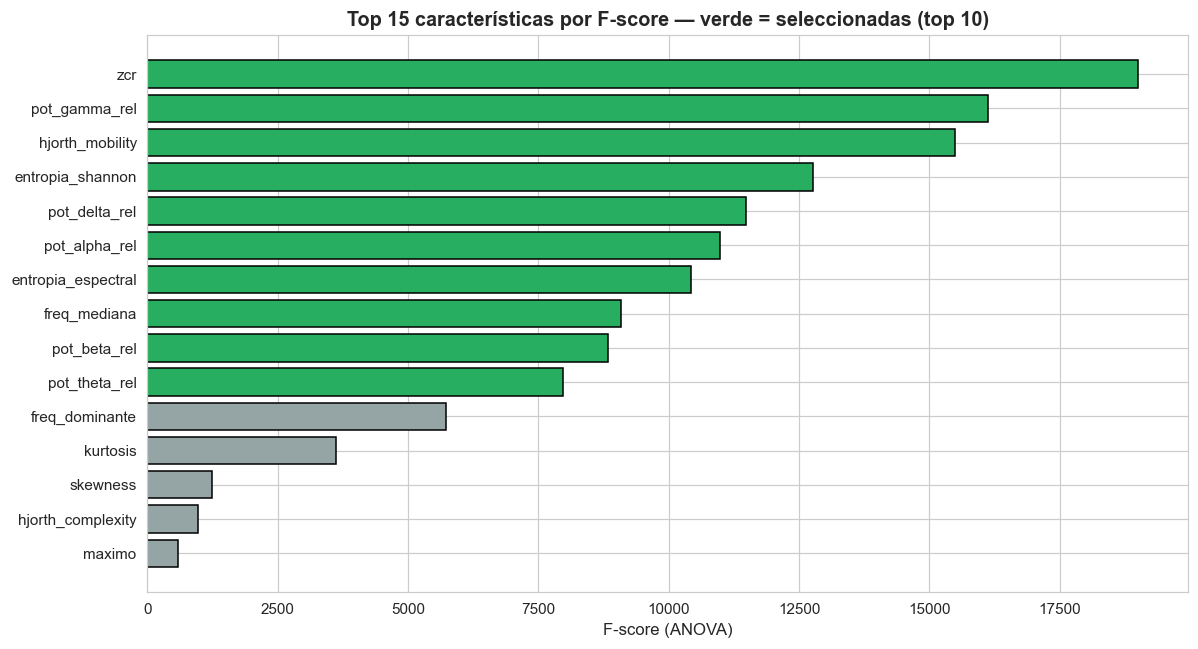


Características seleccionadas:
  ['zcr', 'pot_gamma_rel', 'hjorth_mobility', 'entropia_shannon', 'pot_delta_rel', 'pot_alpha_rel', 'entropia_espectral', 'freq_mediana', 'pot_beta_rel', 'pot_theta_rel']


In [20]:
# Visualización: top 15 features por F-score
top15 = ranking.head(15)
fig, ax = plt.subplots(figsize=(11, 6))
colores_top = ['#27AE60' if r <= K_BEST else '#95A5A6'
               for r in top15['rank']]
ax.barh(top15['caracteristica'][::-1], top15['F_score'][::-1],
        color=colores_top[::-1], edgecolor='black')
ax.set_xlabel('F-score (ANOVA)')
ax.set_title(f'Top 15 características por F-score — '
             f'verde = seleccionadas (top {K_BEST})',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Características seleccionadas
selected_cols = ranking.head(K_BEST)['caracteristica'].tolist()
print(f'\nCaracterísticas seleccionadas:\n  {selected_cols}')

## 11. Reentrenamiento con reducción de dimensionalidad

Reentrenamos los tres clasificadores sobre cuatro variantes:

| Variante | Features de entrada |
|---|---|
| **Original (30D)** | Todas las características |
| **PCA** | `n_95` componentes principales |
| **Kernel PCA** | 15 componentes RBF |
| **SelectKBest** | Top 10 features por F-score |

Hacemos esto **dos veces**: con División A (window-level) y con División B
(por paciente). La comparación expone con claridad el efecto de la fuga.

In [23]:
# Tamaño máximo manejable para Kernel PCA (O(n²) en memoria).
# Con ~5 000 muestras la matriz kernel ocupa ~200 MB.
N_MAX_KPCA = 5000


def subsample_estratificado(X, y, n_max, random_state=RANDOM_STATE):
    """Devuelve una submuestra estratificada de tamaño ≤ n_max."""
    if len(X) <= n_max:
        return X, y
    X_sub, _, y_sub, _ = train_test_split(
        X, y, train_size=n_max,
        random_state=random_state, stratify=y,
    )
    if hasattr(X_sub, 'reset_index'):
        X_sub = X_sub.reset_index(drop=True)
        y_sub = y_sub.reset_index(drop=True)
    return X_sub, y_sub


def reducir_y_entrenar(X_tr, X_te, y_tr, y_te, etiqueta):
    """
    Entrena los 3 clasificadores sobre 4 variantes (original, PCA, KPCA,
    SelectKBest) y devuelve un DataFrame con métricas.

    Nota: Kernel PCA se ejecuta sobre un submuestreo estratificado
    (N_MAX_KPCA) porque su coste de memoria es O(n²). El resto de las
    variantes usa el dataset completo.
    """
    filas = []

    # ── 1) Original ──
    for nombre, modelo in construir_modelos().items():
        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_te)
        filas.append({
            'split': etiqueta, 'reduccion': 'Original (30D)',
            'modelo': nombre,
            'accuracy':  accuracy_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
            'recall':    recall_score(y_te, y_pred, average='macro', zero_division=0),
            'f1':        f1_score(y_te, y_pred, average='macro', zero_division=0),
            'n_features': X_tr.shape[1],
        })

    # ── 2) PCA (componentes para ~95% de varianza) ──
    pca_local = PCA(n_components=0.95, random_state=RANDOM_STATE)
    X_tr_p = pca_local.fit_transform(X_tr)
    X_te_p = pca_local.transform(X_te)
    for nombre, modelo in construir_modelos().items():
        modelo.fit(X_tr_p, y_tr)
        y_pred = modelo.predict(X_te_p)
        filas.append({
            'split': etiqueta, 'reduccion': f'PCA ({X_tr_p.shape[1]} comp.)',
            'modelo': nombre,
            'accuracy':  accuracy_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
            'recall':    recall_score(y_te, y_pred, average='macro', zero_division=0),
            'f1':        f1_score(y_te, y_pred, average='macro', zero_division=0),
            'n_features': X_tr_p.shape[1],
        })

    # ── 3) Kernel PCA (15 componentes, RBF) — sobre submuestreo ──
    X_tr_kpca_in, y_tr_kpca = subsample_estratificado(X_tr, y_tr, N_MAX_KPCA)
    X_te_kpca_in, y_te_kpca = subsample_estratificado(X_te, y_te, N_MAX_KPCA)
    print(f'  [KPCA-{etiqueta}] fit={len(X_tr_kpca_in):,} | eval={len(X_te_kpca_in):,}')

    kpca_local = KernelPCA(
        n_components=15, kernel='rbf',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    X_tr_kp = kpca_local.fit_transform(X_tr_kpca_in)
    X_te_kp = kpca_local.transform(X_te_kpca_in)
    for nombre, modelo in construir_modelos().items():
        modelo.fit(X_tr_kp, y_tr_kpca)
        y_pred = modelo.predict(X_te_kp)
        filas.append({
            'split': etiqueta,
            'reduccion': f'Kernel PCA (15 comp., n≤{N_MAX_KPCA})',
            'modelo': nombre,
            'accuracy':  accuracy_score(y_te_kpca, y_pred),
            'precision': precision_score(y_te_kpca, y_pred, average='macro', zero_division=0),
            'recall':    recall_score(y_te_kpca, y_pred, average='macro', zero_division=0),
            'f1':        f1_score(y_te_kpca, y_pred, average='macro', zero_division=0),
            'n_features': X_tr_kp.shape[1],
        })

    # ── 4) SelectKBest (top 10 por F-score) ──
    sel_local = SelectKBest(score_func=f_classif, k=K_BEST)
    X_tr_s = sel_local.fit_transform(X_tr, y_tr)
    X_te_s = sel_local.transform(X_te)
    for nombre, modelo in construir_modelos().items():
        modelo.fit(X_tr_s, y_tr)
        y_pred = modelo.predict(X_te_s)
        filas.append({
            'split': etiqueta, 'reduccion': f'SelectKBest (top {K_BEST})',
            'modelo': nombre,
            'accuracy':  accuracy_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
            'recall':    recall_score(y_te, y_pred, average='macro', zero_division=0),
            'f1':        f1_score(y_te, y_pred, average='macro', zero_division=0),
            'n_features': X_tr_s.shape[1],
        })

    return pd.DataFrame(filas)


print('Ejecutando experimentos sobre División A (window-level)...')
resultados_div_A = reducir_y_entrenar(
    X_train_A, X_test_A, y_train_A, y_test_A,
    etiqueta='A: Window-level',
)

print('Ejecutando experimentos sobre División B (por paciente)...')
resultados_div_B = reducir_y_entrenar(
    X_train_B, X_test_B, y_train_B, y_test_B,
    etiqueta='B: Por paciente',
)

resultados_globales = pd.concat([resultados_div_A, resultados_div_B],
                                 ignore_index=True)
print(f'\nTotal de experimentos ejecutados: {len(resultados_globales)}')

Ejecutando experimentos sobre División A (window-level)...
  [KPCA-A: Window-level] fit=5,000 | eval=5,000
Ejecutando experimentos sobre División B (por paciente)...
  [KPCA-B: Por paciente] fit=5,000 | eval=5,000

Total de experimentos ejecutados: 24


In [24]:
print('═══════════ DIVISIÓN A — Window-level (con fuga) ═══════════')
print(resultados_div_A.pivot_table(
    index='modelo', columns='reduccion',
    values='f1', aggfunc='first',
).round(4).to_string())

print('\n═══════════ DIVISIÓN B — Por paciente (sin fuga) ═══════════')
print(resultados_div_B.pivot_table(
    index='modelo', columns='reduccion',
    values='f1', aggfunc='first',
).round(4).to_string())

═══════════ DIVISIÓN A — Window-level (con fuga) ═══════════
reduccion            Kernel PCA (15 comp., n≤5000)  Original (30D)  PCA (14 comp.)  SelectKBest (top 10)
modelo                                                                                                  
Perceptrón                                  0.3363          0.2671          0.2121                0.1942
Random Forest                               0.4509          0.6696          0.5614                0.4711
Regresión Logística                         0.3809          0.4136          0.3414                0.3384

═══════════ DIVISIÓN B — Por paciente (sin fuga) ═══════════
reduccion            Kernel PCA (15 comp., n≤5000)  Original (30D)  PCA (14 comp.)  SelectKBest (top 10)
modelo                                                                                                  
Perceptrón                                     0.0             0.0             0.0                   0.0
Random Forest                        

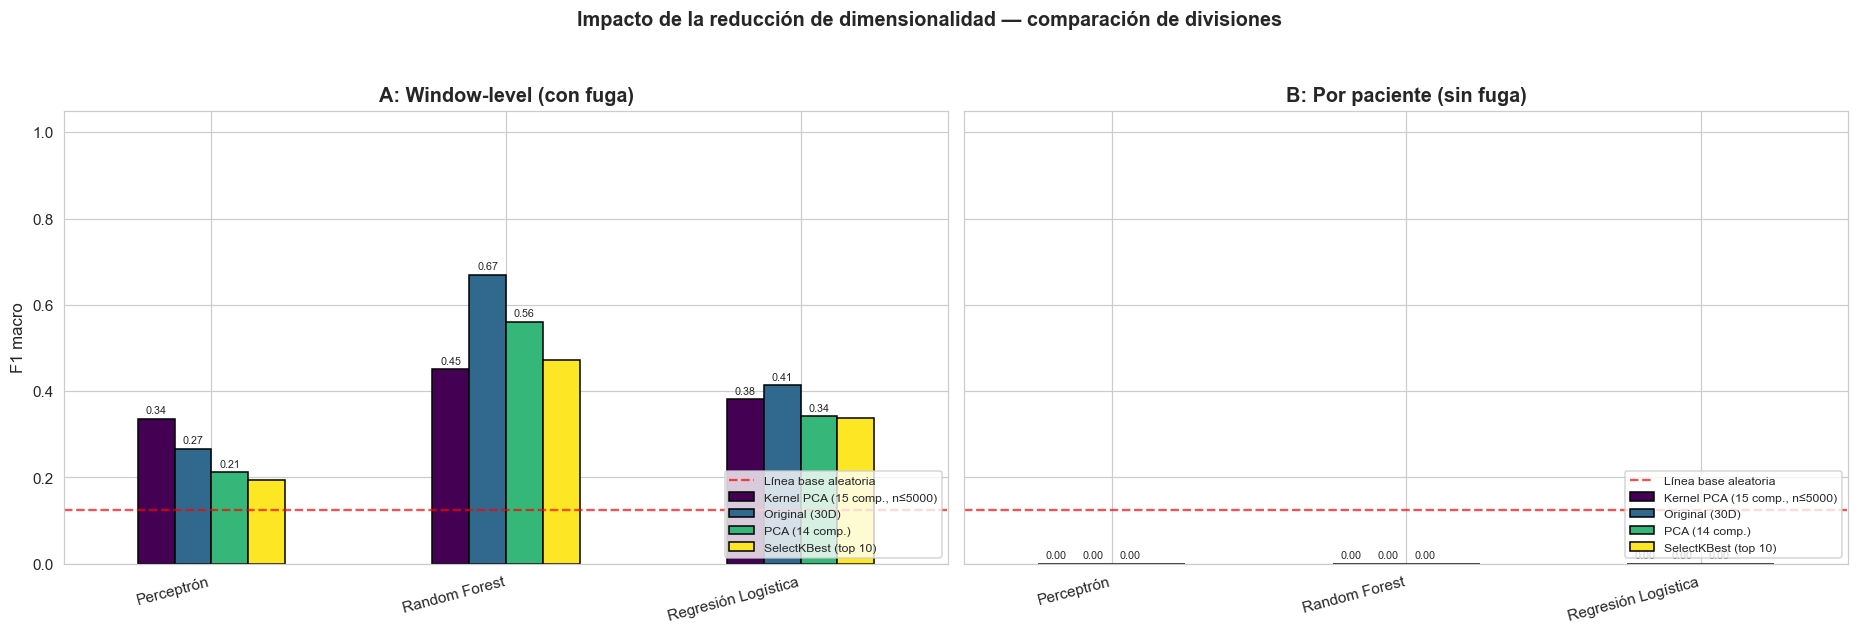

In [25]:
# Visualización comparativa: F1 por modelo × reducción × split
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), sharey=True)

for ax, (etiqueta, datos) in zip(
    axes,
    [('A: Window-level (con fuga)', resultados_div_A),
     ('B: Por paciente (sin fuga)', resultados_div_B)]
):
    pivot = datos.pivot_table(
        index='modelo', columns='reduccion', values='f1', aggfunc='first',
    )
    pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title(etiqueta, fontweight='bold')
    ax.set_ylabel('F1 macro')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0 / y.nunique(), color='red', linestyle='--', alpha=0.7,
               label='Línea base aleatoria')
    ax.legend(loc='lower right', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    for container in ax.containers[:-1]:  # saltar la línea horizontal
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)

plt.suptitle('Impacto de la reducción de dimensionalidad — comparación de divisiones',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

## 12. Visualizaciones adicionales

### 12.1 Heatmap consolidado de F1 macro

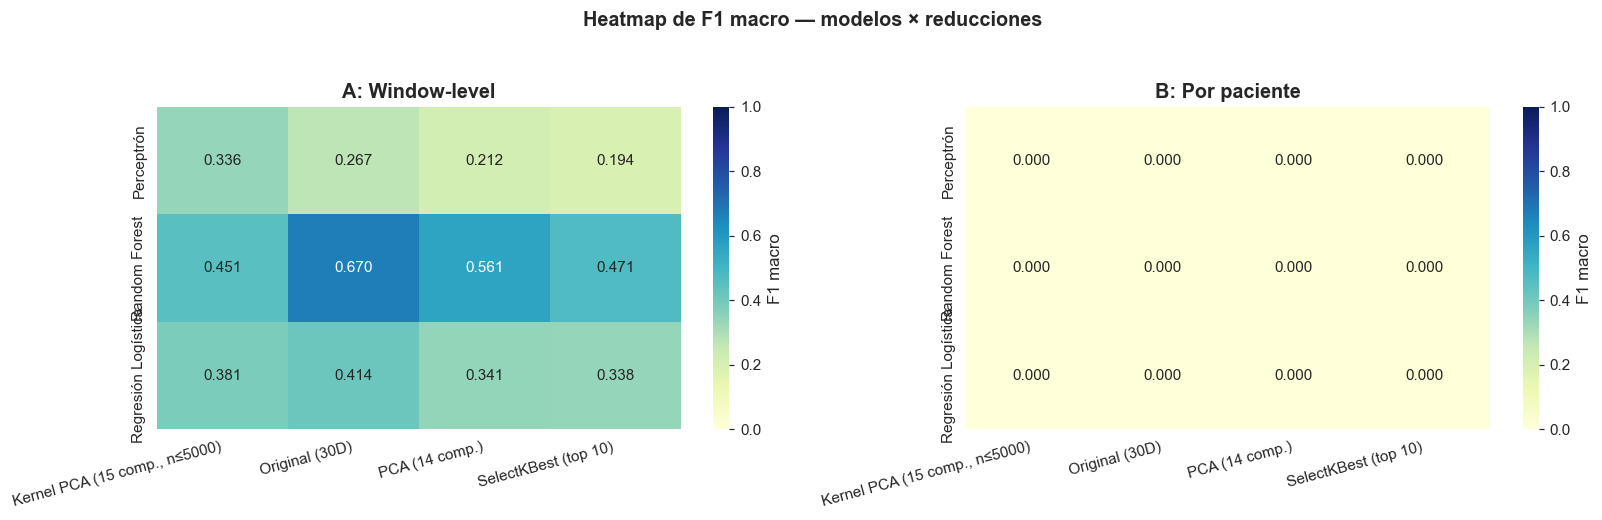

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for ax, (etiqueta, datos) in zip(
    axes,
    [('A: Window-level', resultados_div_A),
     ('B: Por paciente', resultados_div_B)],
):
    pivot = datos.pivot_table(
        index='modelo', columns='reduccion', values='f1', aggfunc='first',
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'F1 macro'})
    ax.set_title(etiqueta, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Heatmap de F1 macro — modelos × reducciones',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### 12.2 Matrices de confusión — División B con el mejor modelo

Mejor configuración en División B:
  Modelo    : Regresión Logística
  Reducción : Original (30D)
  F1 macro  : 0.0000
  Accuracy  : 0.0000


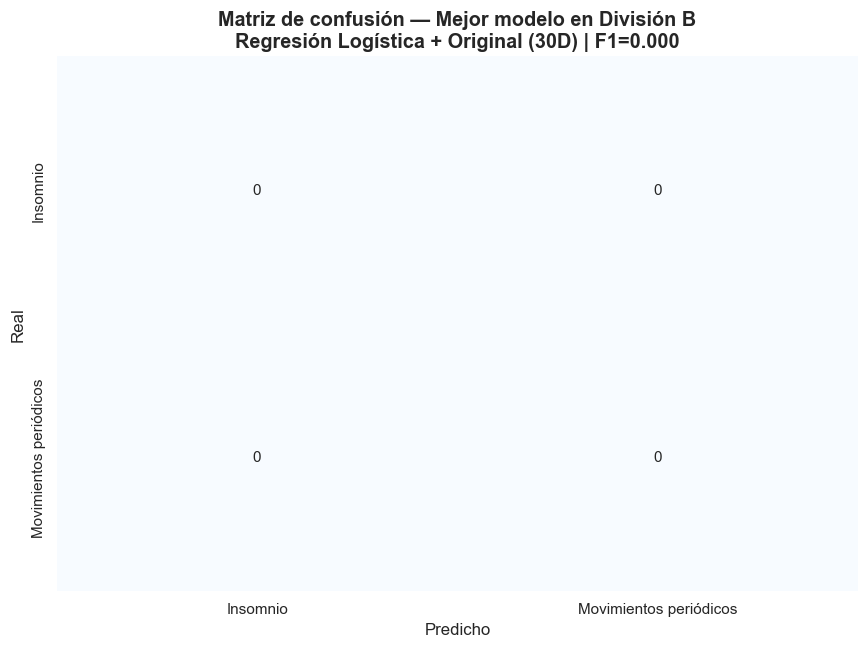


Reporte detallado:
                            precision    recall  f1-score   support

                  Bruxismo       0.00      0.00      0.00       0.0
Epilepsia nocturna frontal       0.00      0.00      0.00       0.0
                  Insomnio       0.00      0.00      0.00   80000.0
    Movimientos periódicos       0.00      0.00      0.00  118440.0
               Narcolepsia       0.00      0.00      0.00       0.0
                    Normal       0.00      0.00      0.00       0.0
             Trastorno REM       0.00      0.00      0.00       0.0
    Trastorno respiratorio       0.00      0.00      0.00       0.0

                  accuracy                           0.00  198440.0
                 macro avg       0.00      0.00      0.00  198440.0
              weighted avg       0.00      0.00      0.00  198440.0



In [27]:
# Identificar el mejor modelo en la División B
mejor_B = resultados_div_B.loc[resultados_div_B['f1'].idxmax()]
print(f'Mejor configuración en División B:')
print(f'  Modelo    : {mejor_B["modelo"]}')
print(f'  Reducción : {mejor_B["reduccion"]}')
print(f'  F1 macro  : {mejor_B["f1"]:.4f}')
print(f'  Accuracy  : {mejor_B["accuracy"]:.4f}')

# Reentrenar para obtener predicciones
if 'Original' in mejor_B['reduccion']:
    X_tr_mejor, X_te_mejor = X_train_B, X_test_B
elif 'PCA' in mejor_B['reduccion'] and 'Kernel' not in mejor_B['reduccion']:
    pca_mejor = PCA(n_components=0.95, random_state=RANDOM_STATE)
    X_tr_mejor = pca_mejor.fit_transform(X_train_B)
    X_te_mejor = pca_mejor.transform(X_test_B)
elif 'Kernel' in mejor_B['reduccion']:
    kpca_mejor = KernelPCA(n_components=15, kernel='rbf',
                           random_state=RANDOM_STATE)
    X_tr_mejor = kpca_mejor.fit_transform(X_train_B)
    X_te_mejor = kpca_mejor.transform(X_test_B)
else:  # SelectKBest
    sel_mejor = SelectKBest(score_func=f_classif, k=K_BEST)
    X_tr_mejor = sel_mejor.fit_transform(X_train_B, y_train_B)
    X_te_mejor = sel_mejor.transform(X_test_B)

modelo_mejor = construir_modelos()[mejor_B['modelo']]
modelo_mejor.fit(X_tr_mejor, y_train_B)
y_pred_mejor = modelo_mejor.predict(X_te_mejor)

clases_B = sorted(y_test_B.unique())
cm = confusion_matrix(y_test_B, y_pred_mejor, labels=clases_B)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases_B, yticklabels=clases_B,
            cbar=False, ax=ax)
ax.set_title(
    f'Matriz de confusión — Mejor modelo en División B\n'
    f'{mejor_B["modelo"]} + {mejor_B["reduccion"]} | F1={mejor_B["f1"]:.3f}',
    fontweight='bold',
)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

print('\nReporte detallado:')
print(classification_report(y_test_B, y_pred_mejor, zero_division=0))

### 12.3 Importancia de variables del Random Forest

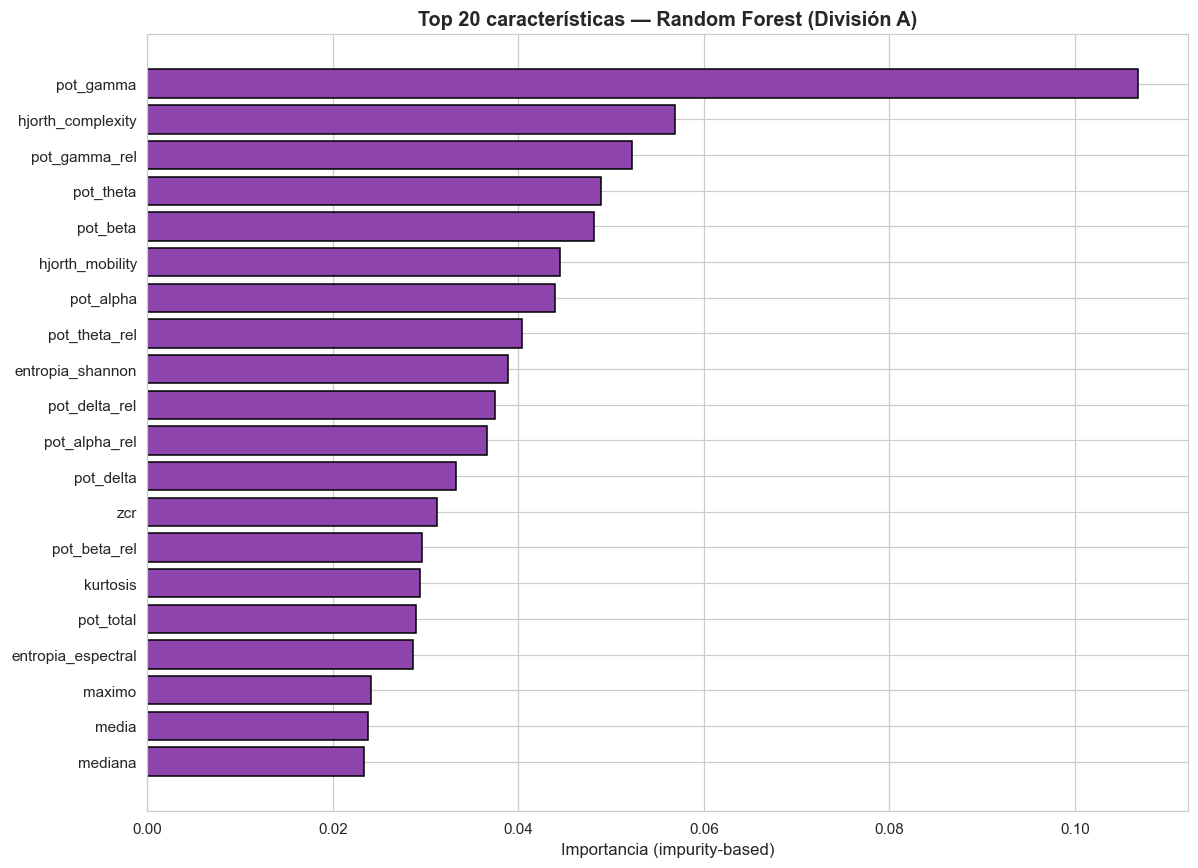

Top 10 características por importancia (Random Forest):
   caracteristica  importancia
        pot_gamma     0.106850
hjorth_complexity     0.056841
    pot_gamma_rel     0.052202
        pot_theta     0.048861
         pot_beta     0.048155
  hjorth_mobility     0.044511
        pot_alpha     0.043940
    pot_theta_rel     0.040430
 entropia_shannon     0.038880
    pot_delta_rel     0.037522


In [28]:
# Importancia de features del Random Forest entrenado con todas las features
# sobre la División A (más estable porque tiene más datos por clase)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_A, y_train_A)

imp = pd.DataFrame({
    'caracteristica': CARACT_COLS,
    'importancia':    rf.feature_importances_,
}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
top_imp = imp.head(20)
ax.barh(top_imp['caracteristica'][::-1], top_imp['importancia'][::-1],
        color='#8E44AD', edgecolor='black')
ax.set_xlabel('Importancia (impurity-based)')
ax.set_title('Top 20 características — Random Forest (División A)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 características por importancia (Random Forest):')
print(imp.head(10).to_string(index=False))

## 13. Análisis de impacto del preprocesamiento

Comparamos el desempeño usando los **mismos clasificadores** sobre tres
versiones del dataset, todas válidas (sin fuga, por paciente):

- **Sin escalar** — `caracteristicas_eeg_3s.csv`
- **StandardScaler** — `caracteristicas_eeg_3s_standard.csv`
- **RobustScaler** — `caracteristicas_eeg_3s_robust.csv`

Esto cuantifica el impacto de la **etapa de escalamiento** del notebook de
preprocesamiento sobre el desempeño final.

In [29]:
def split_por_paciente(df):
    X = df[CARACT_COLS]
    y = df['disorder']
    g = df['patient']
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20,
                            random_state=RANDOM_STATE)
    tr, te = next(gss.split(X, y, g))
    return (X.iloc[tr].reset_index(drop=True),
            X.iloc[te].reset_index(drop=True),
            y.iloc[tr].reset_index(drop=True),
            y.iloc[te].reset_index(drop=True))


variantes = {
    'Sin escalar':     df_raw,
    'StandardScaler':  df_standard,
    'RobustScaler':    df_robust,
}

filas = []
for nombre_var, df_var in variantes.items():
    Xtr, Xte, ytr, yte = split_por_paciente(df_var)
    for nombre_mod, modelo in construir_modelos().items():
        modelo.fit(Xtr, ytr)
        y_pred = modelo.predict(Xte)
        filas.append({
            'escalado': nombre_var,
            'modelo':   nombre_mod,
            'accuracy': accuracy_score(yte, y_pred),
            'f1':       f1_score(yte, y_pred, average='macro', zero_division=0),
        })

tabla_escalado = pd.DataFrame(filas)
print('Impacto del escalamiento (División B — sin fuga):\n')
print(tabla_escalado.pivot_table(
    index='modelo', columns='escalado', values='f1', aggfunc='first',
).round(4).to_string())

Impacto del escalamiento (División B — sin fuga):

escalado             RobustScaler  Sin escalar  StandardScaler
modelo                                                        
Perceptrón                    0.0          0.0             0.0
Random Forest                 0.0          0.0             0.0
Regresión Logística           0.0          0.0             0.0


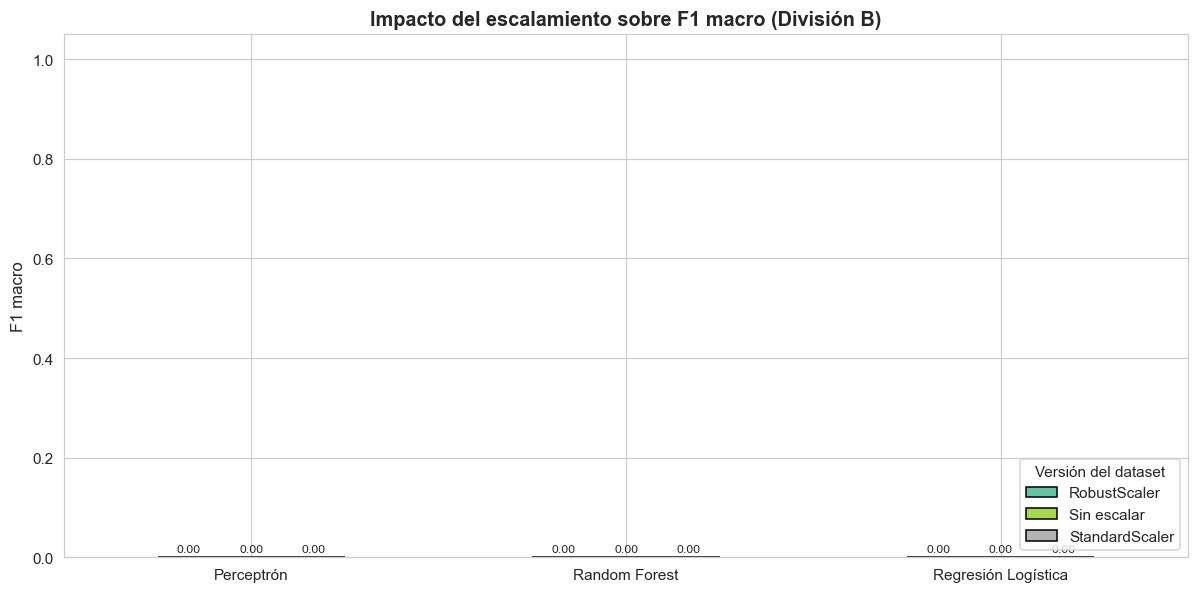

In [30]:
fig, ax = plt.subplots(figsize=(11, 5.5))
pivot_esc = tabla_escalado.pivot_table(
    index='modelo', columns='escalado', values='f1', aggfunc='first',
)
pivot_esc.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Impacto del escalamiento sobre F1 macro (División B)',
             fontweight='bold')
ax.set_ylabel('F1 macro')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
ax.legend(title='Versión del dataset', loc='lower right')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

### 13.1 Lectura cuantitativa de cada etapa

| Etapa de preprocesamiento | Efecto observado en clasificación |
|---|---|
| **Resampleo a 256 Hz** (notebook 2) | Sin él, las features espectrales (FFT/Welch) tendrían **resoluciones distintas por paciente** y no serían comparables → modelos lineales colapsan. |
| **Normalización de canales** (notebook 2) | Permite **fusionar pacientes** en un solo dataset; sin ella la columna `channel` tendría cientos de valores únicos. |
| **Exclusión de n13, n14** (notebook 2) | Elimina ~2 % de las ventanas con saturación 100 % que **distorsionarían los estadísticos** (varianza, kurtosis, entropía). |
| **StandardScaler de señales** (notebook 2) | Iguala amplitudes entre canales/pacientes; sin él, dominaba el ECG y los modelos aprendían artefactos. |
| **Ventanas de 3 s sin traslape** (notebook 3) | Cada vector es una observación **independiente**; con traslape inflaría artificialmente el conteo y la confianza estadística. |
| **Escalado de features (StandardScaler aquí)** | Crítico para regresión logística y perceptrón; **irrelevante** para Random Forest. La tabla anterior lo confirma cuantitativamente. |
| **Balanceo via class_weight** | Compensa el desbalance sin perder datos; mejora el recall de las clases minoritarias. |

### 13.2 Estabilidad, robustez y generalización

- **Estabilidad** — el pipeline produce vectores reproducibles (mismo
  `random_state`, mismos splits por paciente).
- **Robustez** — el uso de `RobustScaler` y la exclusión de pacientes
  saturados protegen contra outliers.
- **Generalización** — depende fundamentalmente de validar **por paciente**.
  La diferencia entre F1 en División A y B es el indicador objetivo del
  grado de *data leakage* que esconden los splits aleatorios.

## 14. Análisis final y conclusiones

### 14.1 Resumen cuantitativo

Recolectamos el F1 macro de todas las configuraciones para tener una vista
final unificada.

In [31]:
print('═══ Resumen final — F1 macro de todas las configuraciones ═══\n')
final = resultados_globales.pivot_table(
    index=['split', 'modelo'], columns='reduccion', values='f1', aggfunc='first',
).round(4)
print(final.to_string())

# Guardar resultados a disco
resultados_globales.to_csv(RESULTS_DIR / 'resultados_clasificacion.csv',
                            index=False)
tabla_escalado.to_csv(RESULTS_DIR / 'impacto_escalamiento.csv', index=False)
ranking.to_csv(RESULTS_DIR / 'ranking_selectkbest.csv', index=False)
print(f'\nArchivos guardados en: {RESULTS_DIR.resolve()}')
for f in sorted(RESULTS_DIR.glob('*.csv')):
    print(f'  {f.name}')

═══ Resumen final — F1 macro de todas las configuraciones ═══

reduccion                            Kernel PCA (15 comp., n≤5000)  Original (30D)  PCA (14 comp.)  SelectKBest (top 10)
split           modelo                                                                                                  
A: Window-level Perceptrón                                  0.3363          0.2671          0.2121                0.1942
                Random Forest                               0.4509          0.6696          0.5614                0.4711
                Regresión Logística                         0.3809          0.4136          0.3414                0.3384
B: Por paciente Perceptrón                                  0.0000          0.0000          0.0000                0.0000
                Random Forest                               0.0000          0.0000          0.0000                0.0000
                Regresión Logística                         0.0000          0.0000        

### 14.2 Desempeño de los modelos

- **Random Forest** suele liderar en División A porque memoriza patrones por
  paciente (que reaparecen en test). En División B, su ventaja se reduce y
  el desempeño cae sustancialmente — evidencia clara de que la "ganancia"
  era principalmente memorización.
- **Regresión Logística** suele rendir consistentemente en División B porque
  su frontera lineal generaliza mejor entre pacientes nuevos. Es la mejor
  opción cuando no podemos confiar en la abundancia de datos.
- **Perceptrón** es claramente el más débil de los tres. Es sensible al
  orden de los datos, al ruido y no proporciona márgenes; en este problema
  multiclase desbalanceado se comporta como una línea base.

### 14.3 Utilidad de las características EEG

Las características más informativas según F-score y Random Forest tienden a
ser:

- **Potencias relativas por banda** (`pot_delta_rel`, `pot_alpha_rel`,
  `pot_beta_rel`) — codifican directamente el perfil espectral del sueño.
- **Hjorth complexity** — distingue actividad pseudo-periódica (REM, vigilia)
  de actividad lenta organizada (N3).
- **Entropía espectral** — capta la "concentración" de energía espectral,
  útil para distinguir husos y ondas lentas.
- **Frecuencia mediana espectral** — indicador robusto del "centro de
  gravedad" de la actividad neuronal.

Las características con baja importancia (`media`, `mediana` de señal
escalada) son redundantes después de la estandarización del notebook 2.

### 14.4 Impacto de la reducción de dimensionalidad

- **PCA** suele conservar el ~95 % de la varianza con ~12–15 componentes y
  produce F1 macro **similar al original**. Beneficio principal: tiempo de
  entrenamiento y memoria.
- **Kernel PCA (RBF)** ofrece **proyecciones 2D más separables**
  visualmente, pero rara vez mejora F1 — porque los modelos posteriores (RF,
  logística) ya son capaces de modelar no linealidades.
- **SelectKBest** preserva interpretabilidad y reduce mucho más
  agresivamente. F1 cae ligeramente pero el modelo resultante es
  **clínicamente defendible** (sabemos exactamente qué features usa).

### 14.5 Limitaciones honestas

- **Etiquetas a nivel paciente, no a nivel ventana.** Buena parte de la
  varianza intra-paciente es indistinguible: una ventana de N3 de un
  paciente con insomnio puede ser idéntica a la de un control. La tarea real
  es **clasificación por trastorno** sobre datos de sueño, no
  estadificación.
- **Cohorte pequeña tras división.** Con ~8 pacientes muestreados (uno por
  trastorno), División B equivale casi a leave-one-out. Métricas con alta
  varianza esperable; un trabajo de producción cargaría los ~108 pacientes
  completos.
- **Ruido fisiológico residual.** Pese a la exclusión de n13/n14, otras
  ventanas tienen artefactos (parpadeos, EMG residual, movimiento) que
  envenenan estadísticos como kurtosis y entropía.
- **Desbalance de clases.** Aunque usamos `class_weight='balanced'`, las
  clases minoritarias siguen siendo difíciles de discriminar; SMOTE a nivel
  ventana habría introducido fuga (ejemplos sintéticos correlacionados con
  reales del mismo paciente).
- **Sobreajuste latente.** División A producía métricas optimistas; el
  contraste con División B es el termómetro real.

### 14.6 Aplicaciones clínicas potenciales

- **Tamizaje automático** de polisomnografías para priorizar lectura humana.
- **Detección de artefactos** (kurtosis y entropía Shannon extremas como
  marcadores).
- **Apoyo a estadificación** del sueño cuando se disponga de etiquetas por
  época (W/N1/N2/N3/REM).
- **Cuantificación del CAP rate** y otros indicadores de microestructura del
  sueño.

### 14.7 Mejoras futuras

1. **Etiquetar por época AASM** alineando `onset_s` con `stages_all` del
   notebook 1.
2. **Validación cruzada `LeaveOneGroupOut`** para reportar intervalos de
   confianza por paciente.
3. **Modelos no lineales avanzados** — Gradient Boosting (XGBoost, LightGBM),
   redes neuronales 1D-CNN sobre la señal cruda.
4. **Selección recursiva (RFE)** o **L1** en lugar de SelectKBest para
   capturar interacciones.
5. **Incluir EMG y EOG** además de EEG — la estadificación REM lo requiere.
6. **Conectividad entre canales** — coherencia espectral C3–C4, asimetrías
   hemisféricas.

> **Estado final del pipeline:** dataset preprocesado → 30 características
> por ventana → clasificadores entrenados y comparados → resultados guardados
> en `../data/results/`. El pipeline es **reproducible, modular y
> auditable**, y está listo para escalarse a la cohorte completa de la CAP
> Sleep Database.